# Aircraft Engine Predictive Maintenance

## Notebook 6: Model Evaluation & Explainable AI (SHAP)

### Objectives

- Load trained XGBoost model
- Evaluate predictions
- Plot Actual vs Predicted
- Residual Analysis
- Explain predictions using SHAP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv("../dataset/processed_train.csv")

X = data.drop("RUL", axis=1)

y = data["RUL"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [3]:
model = joblib.load("../models/xgboost_model.pkl")

In [4]:
prediction = model.predict(X_test)

In [5]:
mae = mean_absolute_error(y_test, prediction)

rmse = np.sqrt(mean_squared_error(y_test, prediction))

r2 = r2_score(y_test, prediction)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

MAE : 6.669827323546848
RMSE : 9.21259174984808
R² : 0.9814235822720448


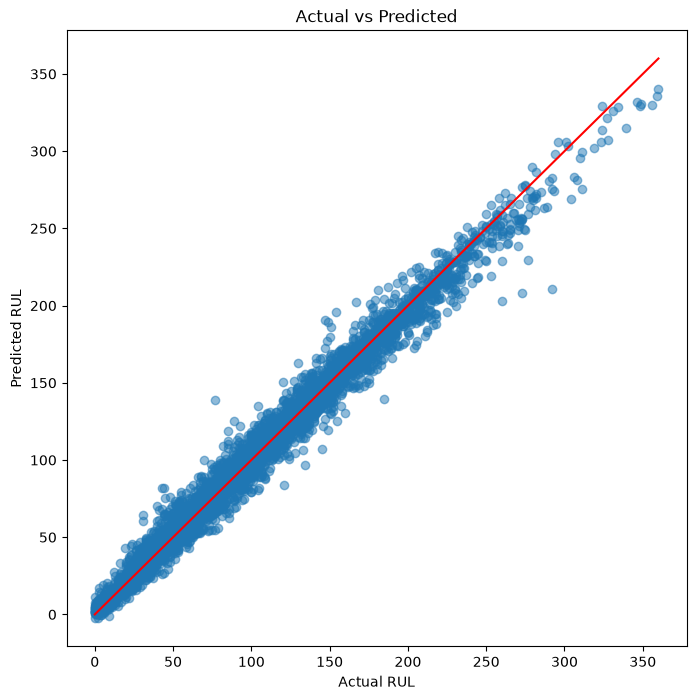

In [6]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    prediction,
    alpha=0.5
)

plt.plot(
    [0, max(y_test)],
    [0, max(y_test)],
    color="red"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted")

plt.show()

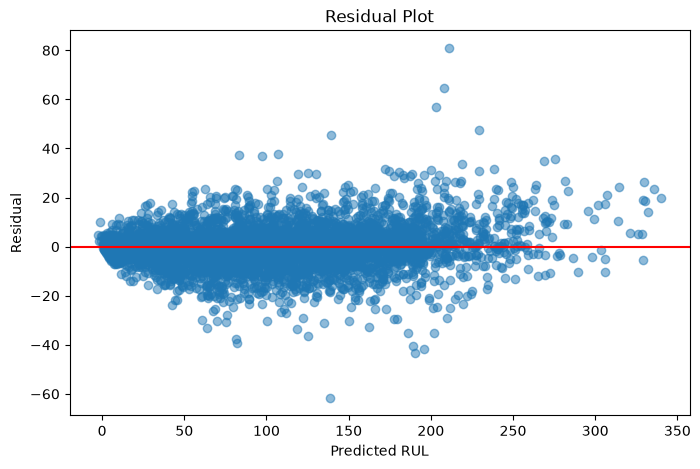

In [7]:
residual = y_test - prediction

plt.figure(figsize=(8,5))

plt.scatter(
    prediction,
    residual,
    alpha=0.5
)

plt.axhline(0, color="red")

plt.xlabel("Predicted RUL")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

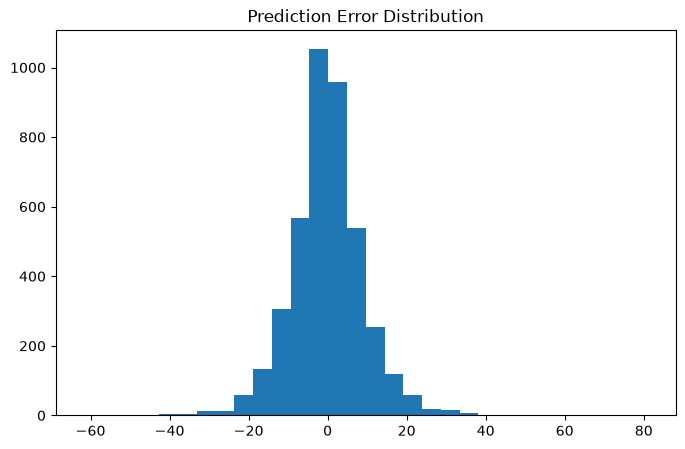

In [8]:
plt.figure(figsize=(8,5))

plt.hist(
    residual,
    bins=30
)

plt.title("Prediction Error Distribution")

plt.show()

In [9]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
1,cycle,0.365453
11,sensor_11,0.148349
6,sensor_4,0.117107
0,engine_id,0.080370
12,sensor_12,0.056406
10,sensor_9,0.047112
8,sensor_7,0.034893
15,sensor_15,0.021530
13,sensor_13,0.021087
14,sensor_14,0.020474


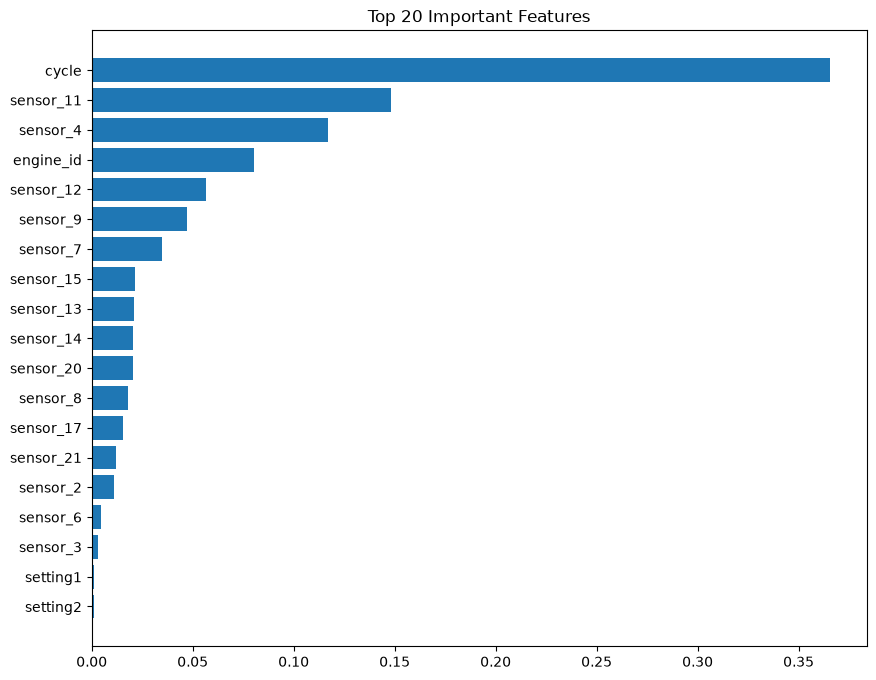

In [10]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:20],
    importance["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

In [11]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

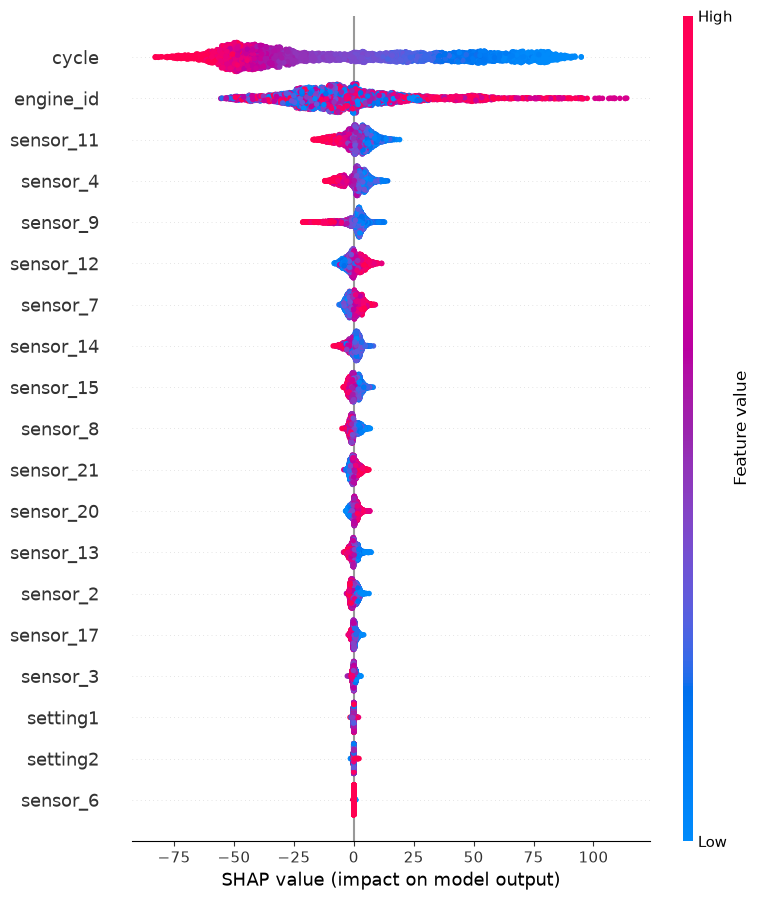

In [12]:
shap.summary_plot(
    shap_values,
    X_test
)

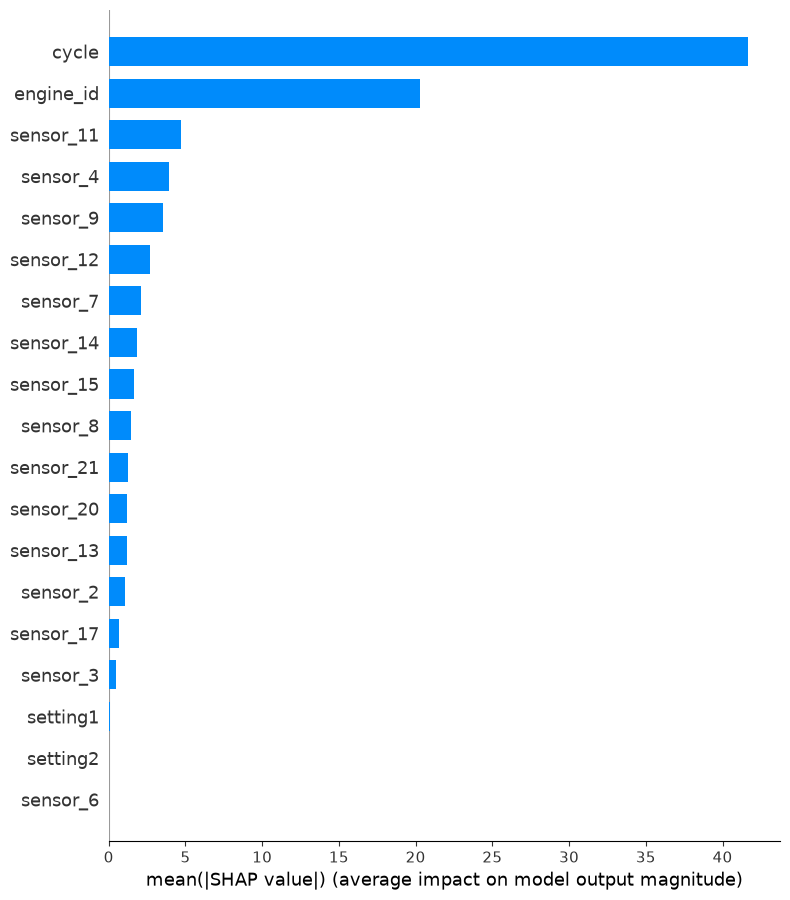

In [13]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

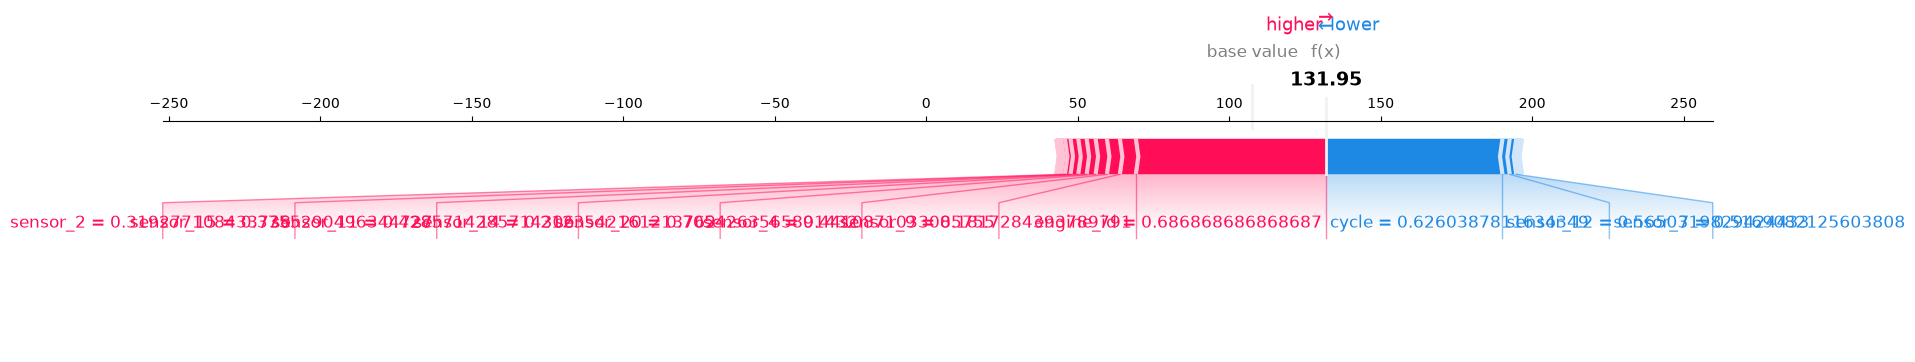

In [14]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0],
    matplotlib=True
)